#Dataset info :

*   Features are labled v1 .. v28 due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.
*   Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
*   The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning.
*   Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

*    **Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.**

*    [Dataset Link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


In [1]:
!pip install alibi

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, mean_absolute_error, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from alibi.explainers import ALE
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [5]:
file_path = "creditcard.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
)

<ipython-input-5-343c1a66d6fe>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


In [6]:
df.dataframeName = 'creditcard.csv'

In [7]:
X = df.drop(columns = "Class")
y = df["Class"]

In [8]:
feature_names = X.columns

# Preprocessing

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_train_normal = X_train[y_train == 0]  # Only normal transactions for training

X_val, X_test_final, y_val, y_test_final = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [11]:
input_dim = X_train_normal.shape[1]
encoding_dim = 14

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(encoding_dim, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(input_dim, activation='linear')  # Reconstruct input
])

autoencoder.compile(optimizer='adam', loss='mse')

# Early stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [12]:
# Predict reconstruction errors on test set
reconstructions = autoencoder.predict(X_test)
reconstruction_errors = np.mean(np.square(reconstructions - X_test), axis=1)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [13]:
autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=100,
    batch_size=128,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.8732 - val_loss: 0.6212
Epoch 2/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6967 - val_loss: 0.5612
Epoch 3/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6443 - val_loss: 0.5377
Epoch 4/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.6346 - val_loss: 0.5125
Epoch 5/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6269 - val_loss: 0.5010
Epoch 6/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5981 - val_loss: 0.4917
Epoch 7/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.6047 - val_loss: 0.4840
Epoch 8/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5918 - val_loss: 0.4872
Epoch 9/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.5878 - val_loss: 0.4775
Epoch 10/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5864 - val_loss: 0.4778
Epoch 11/100
1555/1555 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5842 - val_loss: 0.4751
Epoch 12/100
1555

In [14]:
reconstructions_val = autoencoder.predict(X_val)
reconstruction_errors_val = np.mean(np.square(reconstructions_val - X_val), axis=1)
threshold = np.percentile(reconstruction_errors_val, 95)  # 95th percentile for anomaly detection

# Predict on test set
reconstructions_test = autoencoder.predict(X_test_final)
reconstruction_errors_test = np.mean(np.square(reconstructions_test - X_test_final), axis=1)

# Normalize errors to [0,1] for y_prob (for regression metrics)
y_prob = (reconstruction_errors_test - reconstruction_errors_test.min()) / (reconstruction_errors_test.max() - reconstruction_errors_test.min())
y_pred = (reconstruction_errors_test > threshold).astype(int)

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [15]:
acc = accuracy_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
mse = mean_squared_error(y_test_final, y_prob)
mae = mean_absolute_error(y_test_final, y_prob)
rmse = np.sqrt(mse)
cm = confusion_matrix(y_test_final, y_pred)

# Print metrics
print(f"Accuracy: {acc}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print("Confusion Matrix:\n", cm)

Accuracy: 0.9526239408267403
F1 Score: 0.05772811918063315
Precision: 0.02980769230769231
Recall: 0.9117647058823529
MSE: 0.001121371324535257
MAE: 0.005501561006088618
RMSE: 0.03348688287277956
Confusion Matrix:
 [[40636  2018]
 [    6    62]]


# XAI Techniques

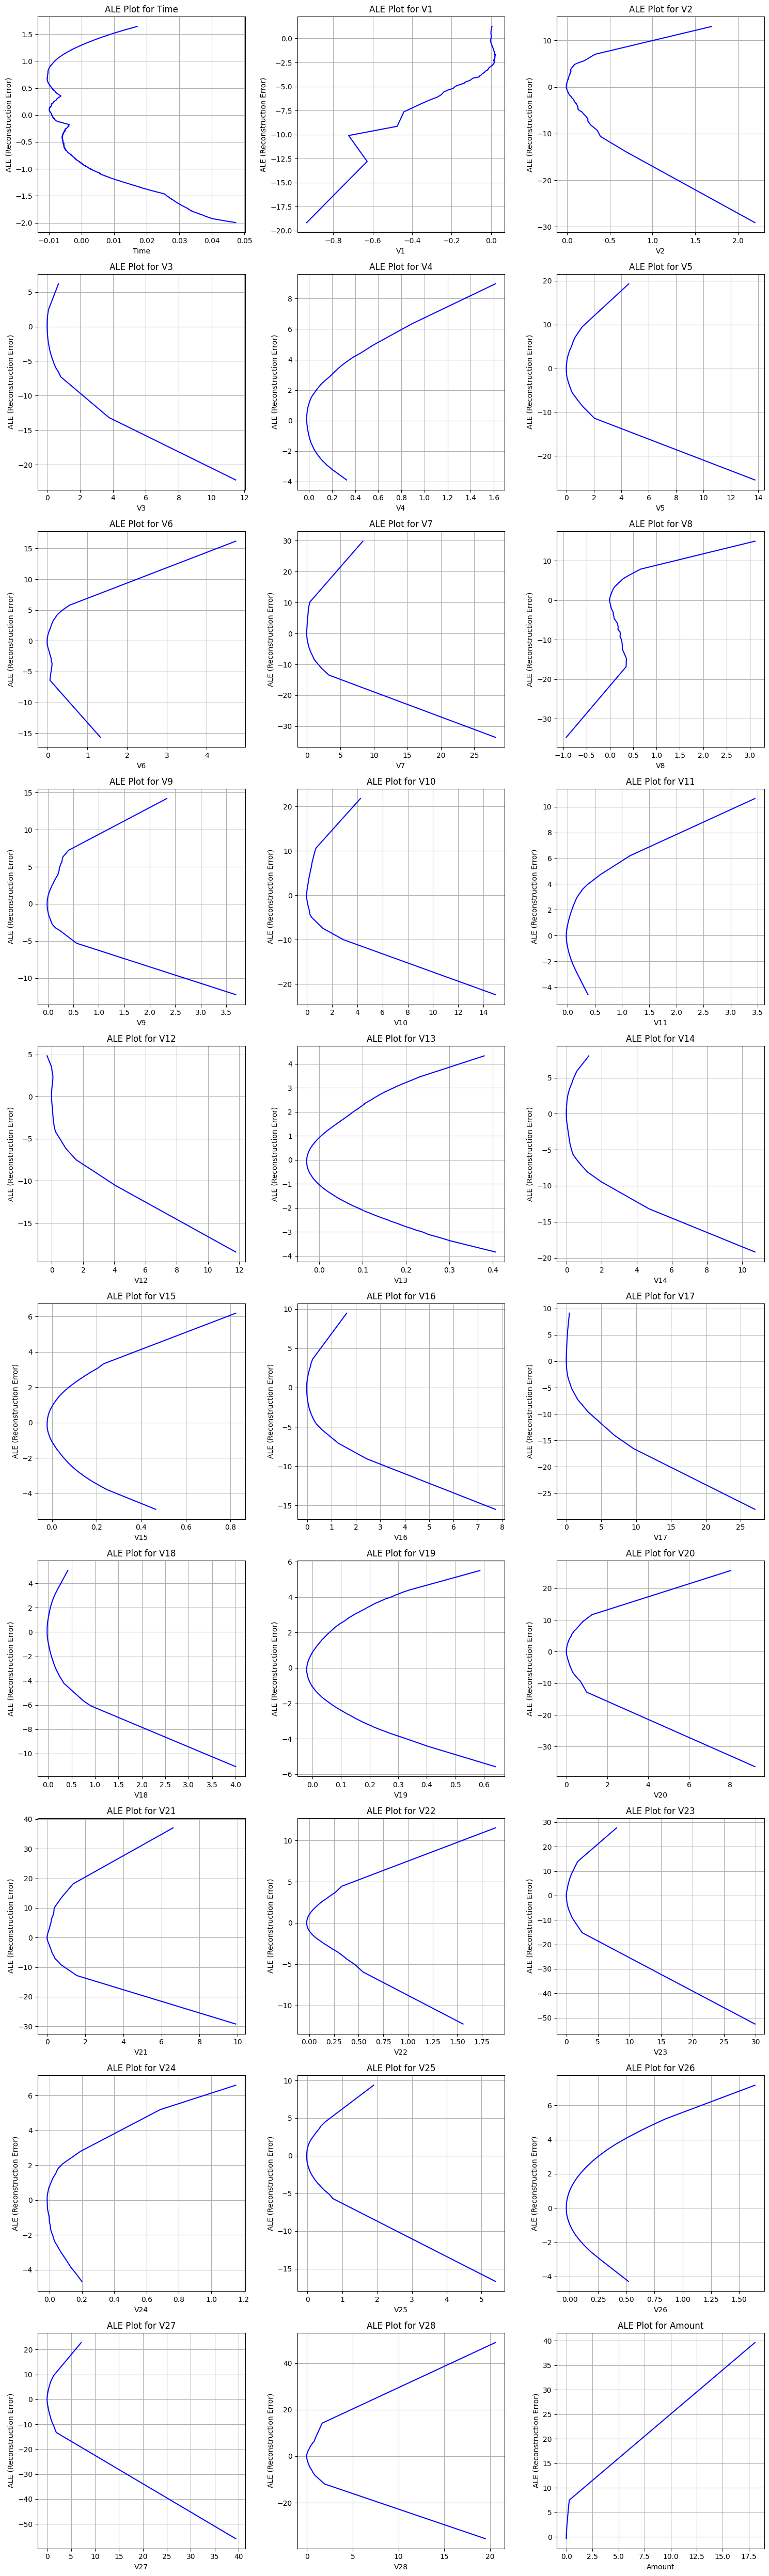

In [33]:
# ALE
def predict_function(X):
    reconstructions = autoencoder.predict(X, verbose=0)
    return np.mean(np.square(reconstructions - X), axis=1)

ale = ALE(predict_function, feature_names=feature_names, target_names=['Reconstruction Error'])

ale_exp = ale.explain(X_test_final)

num_features = len(feature_names)
n_cols = 3
n_rows = (num_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(feature_names):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.plot(ale_exp.ale_values[i], ale_exp.feature_values[i], 'b-')
    plt.title(f'ALE Plot for {feature}')
    plt.xlabel(feature)
    plt.ylabel('ALE (Reconstruction Error)')
    plt.grid(True)
plt.tight_layout()


Surrogate Model (Decision Tree) Accuracy: 0.96865783437105


[Text(0.5, 0.875, 'V1 <= -1.991\ngini = 0.093\nsamples = 42722\nvalue = [40644, 2078]\nclass = Normal'),
 Text(0.25, 0.625, 'V1 <= -3.333\ngini = 0.408\nsamples = 1245\nvalue = [356, 889]\nclass = Fraud'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'V1 <= -3.653\ngini = 0.036\nsamples = 436\nvalue = [8, 428]\nclass = Fraud'),
 Text(0.0625, 0.125, 'gini = 0.012\nsamples = 343\nvalue = [2, 341]\nclass = Fraud'),
 Text(0.1875, 0.125, 'gini = 0.121\nsamples = 93\nvalue = [6, 87]\nclass = Fraud'),
 Text(0.375, 0.375, 'V8 <= -0.31\ngini = 0.49\nsamples = 809\nvalue = [348.0, 461.0]\nclass = Fraud'),
 Text(0.3125, 0.125, 'gini = 0.223\nsamples = 243\nvalue = [31, 212]\nclass = Fraud'),
 Text(0.4375, 0.125, 'gini = 0.493\nsamples = 566\nvalue = [317, 249]\nclass = Normal'),
 Text(0.75, 0.625, 'V8 <= -0.942\ngini = 0.056\nsamples = 41477\nvalue = [40288, 1189]\nclass = Normal'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'V23 <= -3.782\ngini = 0.403\nsamples = 1362\nvalue = [981.

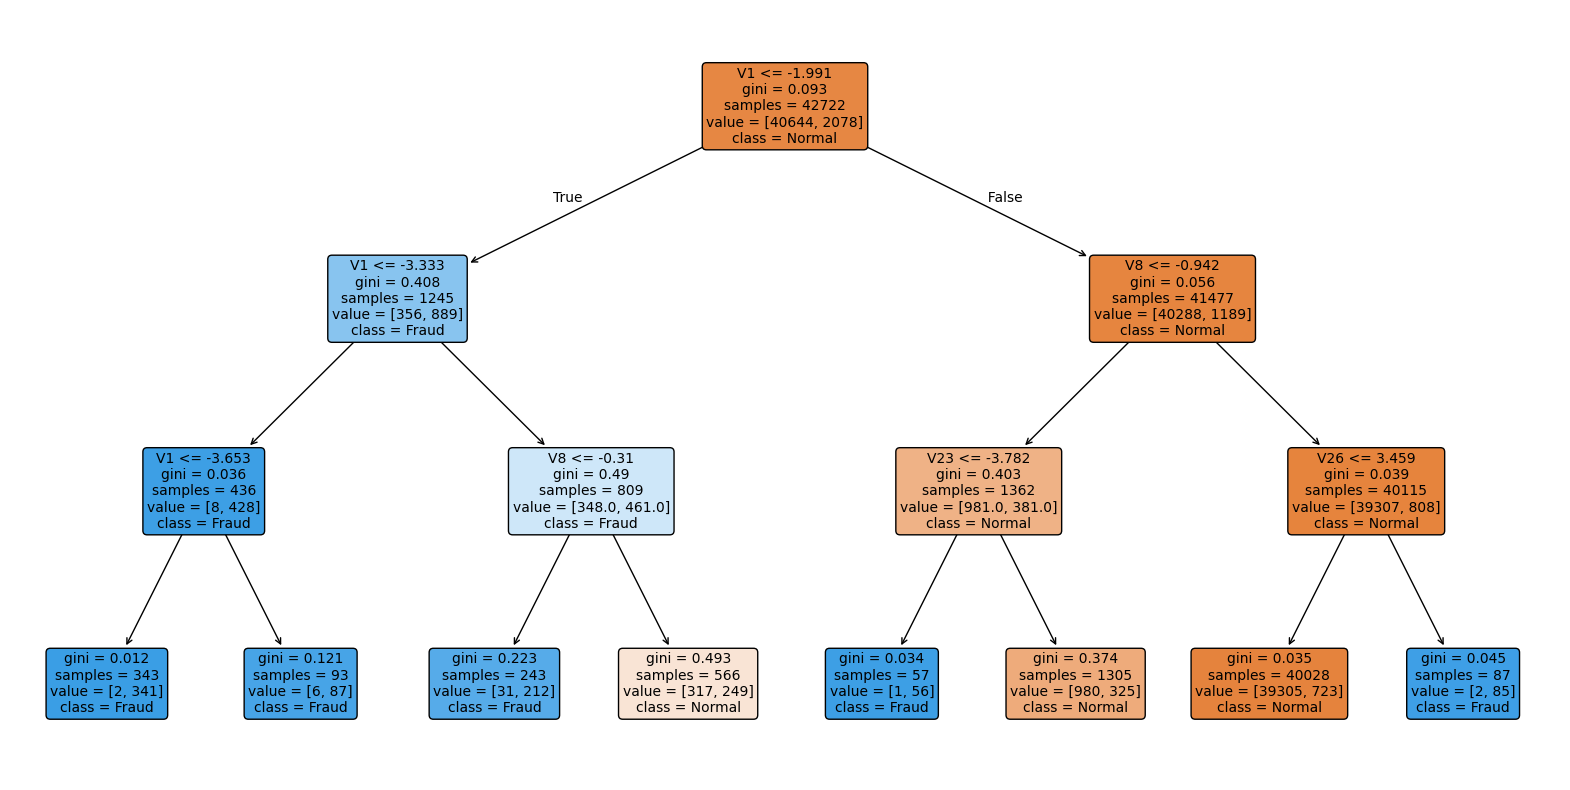

In [35]:
# Surrogate Model
surrogate_model = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate_model.fit(X_test_final, y_pred)

surrogate_pred = surrogate_model.predict(X_test_final)
surrogate_acc = accuracy_score(y_pred, surrogate_pred)
print(f"\nSurrogate Model (Decision Tree) Accuracy: {surrogate_acc}")

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    surrogate_model,
    feature_names=feature_names,
    class_names=['Normal', 'Fraud'],
    filled=True,
    rounded=True,
    fontsize=10
)

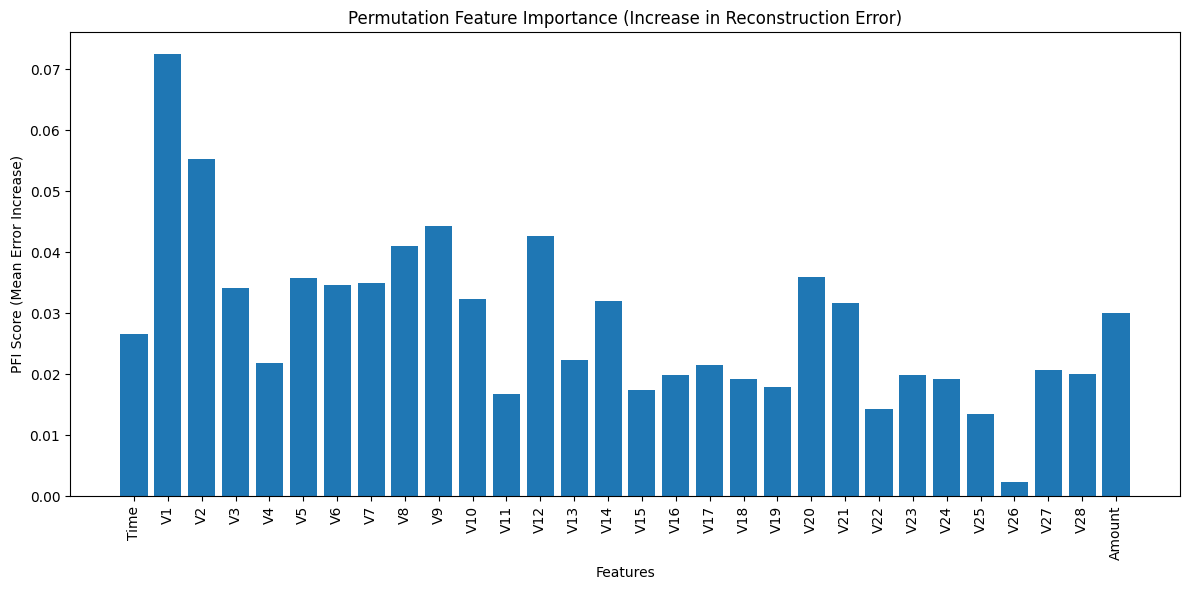

In [36]:
# Permutation Feature Importance
n_permutations = 5
pfi_scores = np.zeros(len(feature_names))
baseline_error = predict_function(X_test_final).mean()

for i in range(len(feature_names)):
    X_permuted = X_test_final.copy()
    errors = []
    for _ in range(n_permutations):
        np.random.shuffle(X_permuted[:, i])
        permuted_error = predict_function(X_permuted).mean()
        errors.append(permuted_error - baseline_error)
    pfi_scores[i] = np.mean(errors)

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_names)), pfi_scores, tick_label=feature_names)
plt.xticks(rotation=90)
plt.title('Permutation Feature Importance (Increase in Reconstruction Error)')
plt.xlabel('Features')
plt.ylabel('PFI Score (Mean Error Increase)')
plt.tight_layout()

  0%|          | 0/100 [00:00<?, ?it/s]

Shape of X_test_final[:100]: (100, 30)
Shape of shap_values: (100, 30)


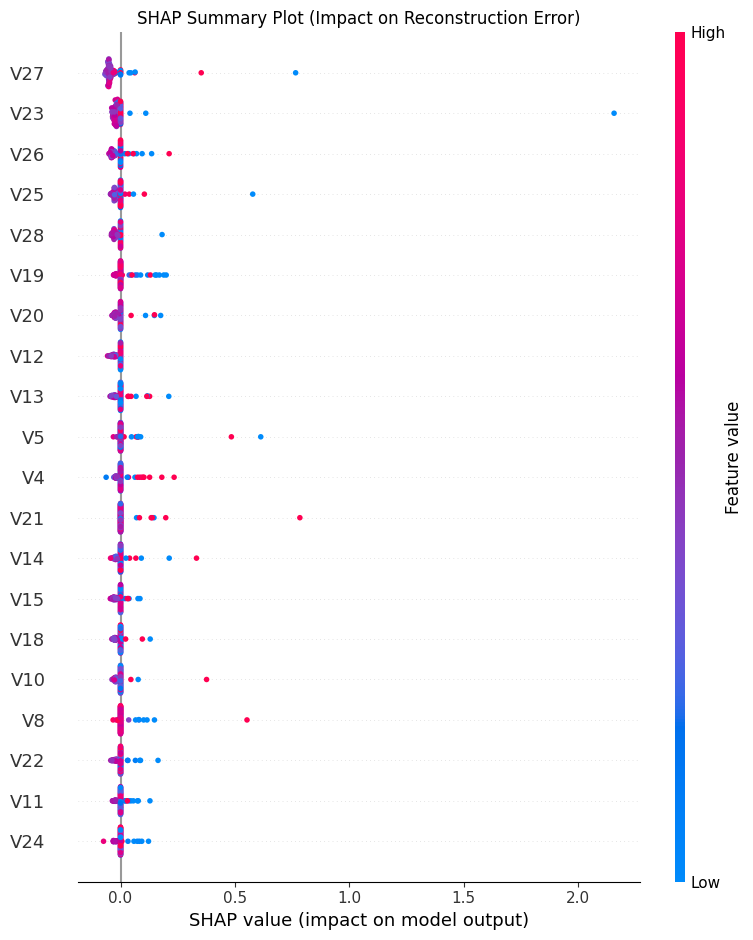

In [16]:
import shap
def model_wrapper(x):
    reconstructions = autoencoder.predict(x, verbose=0)
    return np.mean(np.square(reconstructions - x), axis=1)

explainer = shap.KernelExplainer(model_wrapper, X_train_normal[:100])
shap_values = explainer.shap_values(X_test_final[:100])

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_final[:100], feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean Absolute SHAP Values for Reconstruction Error)")
plt.tight_layout()
plt.savefig("shap_summary_bar.png")
plt.close()

# Beeswarm plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_final[:100], feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Impact on Reconstruction Error)")
plt.tight_layout()

/usr/local/lib/python3.11/dist-packages/shap/plots/_scatter.py:641: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


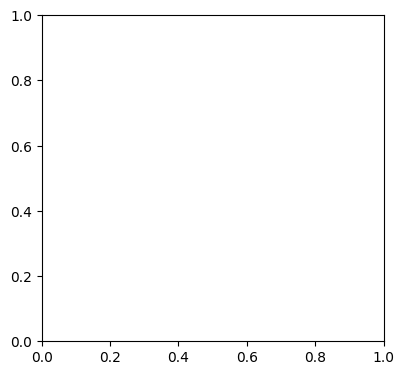

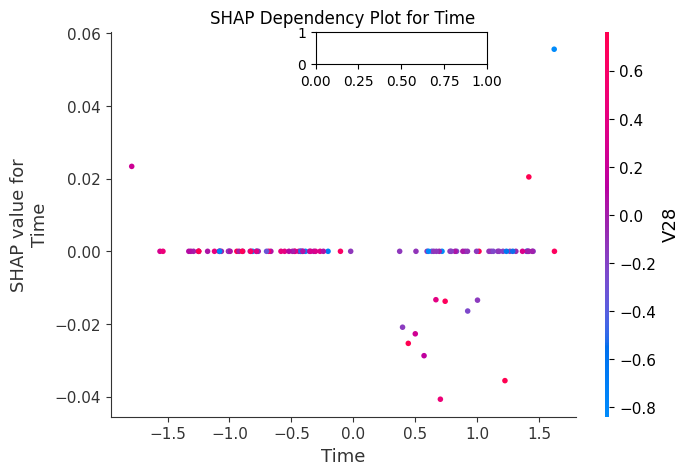

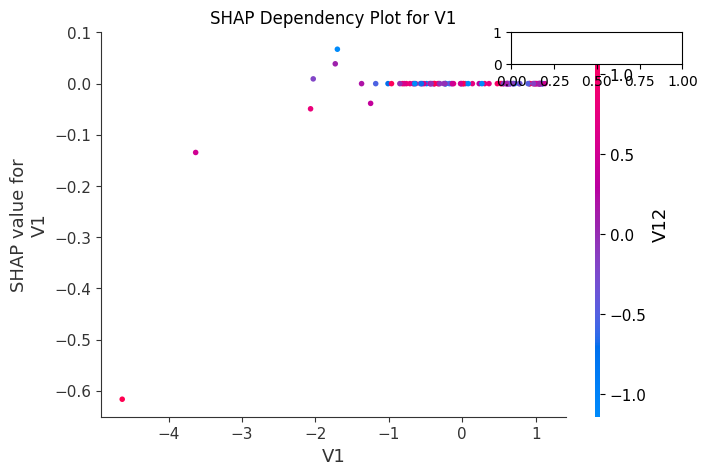

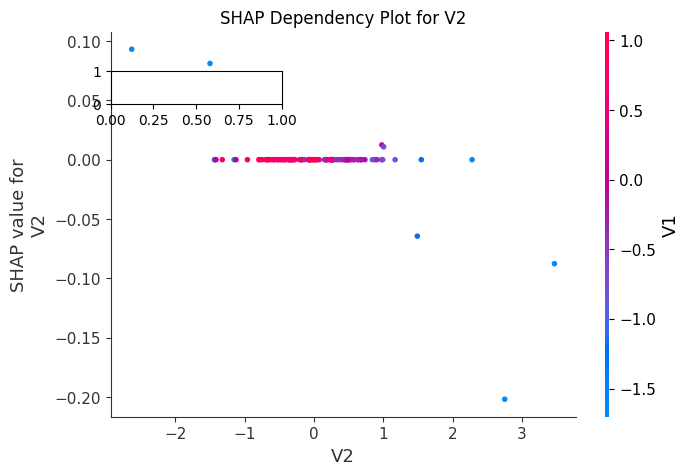

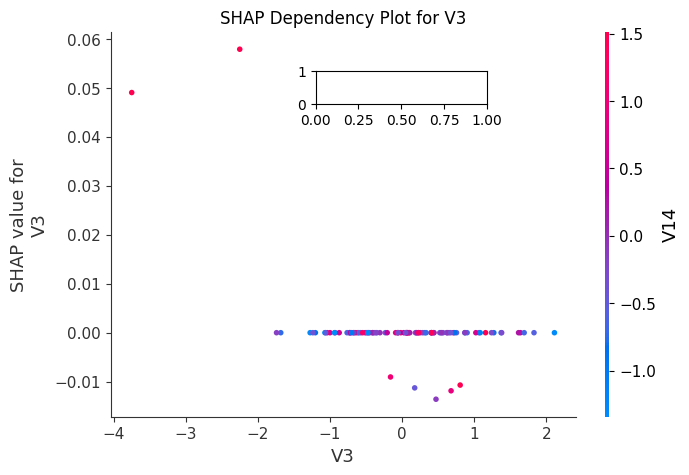

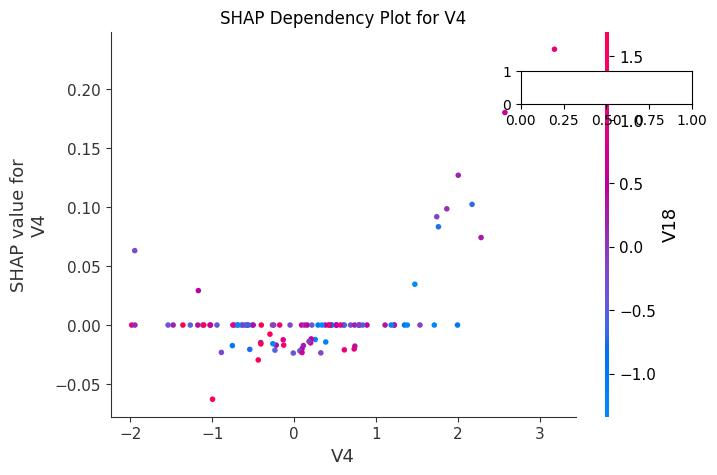

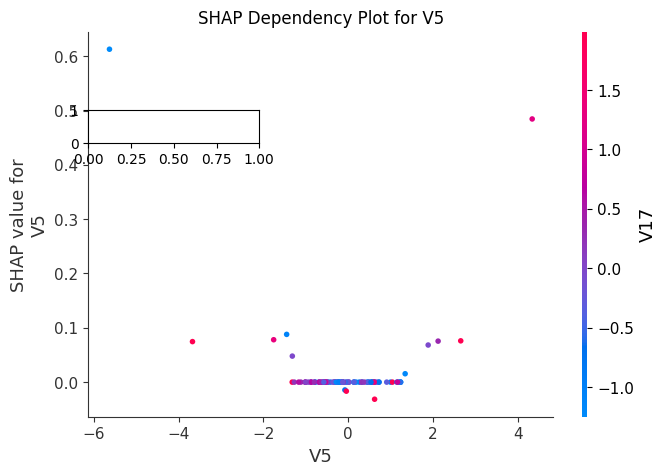

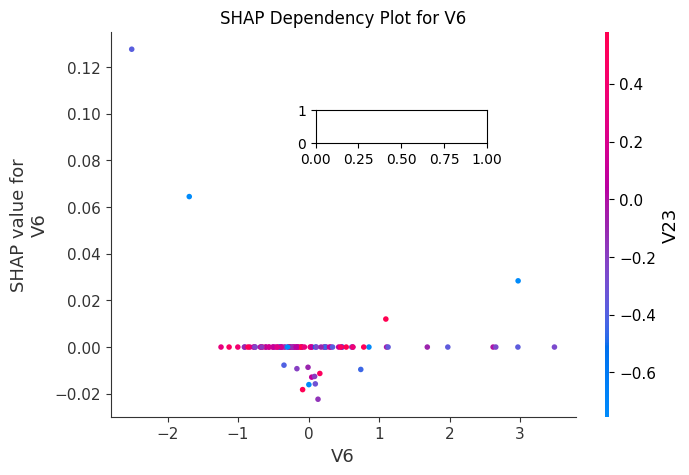

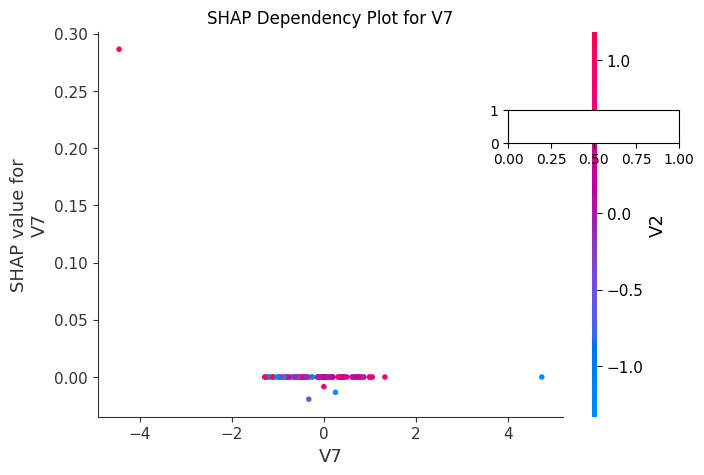

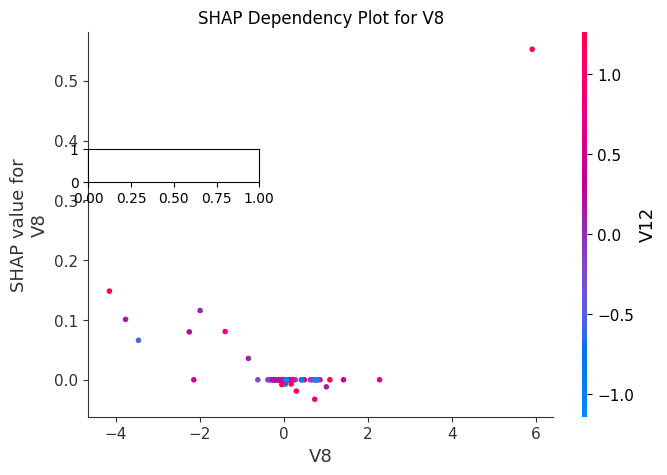

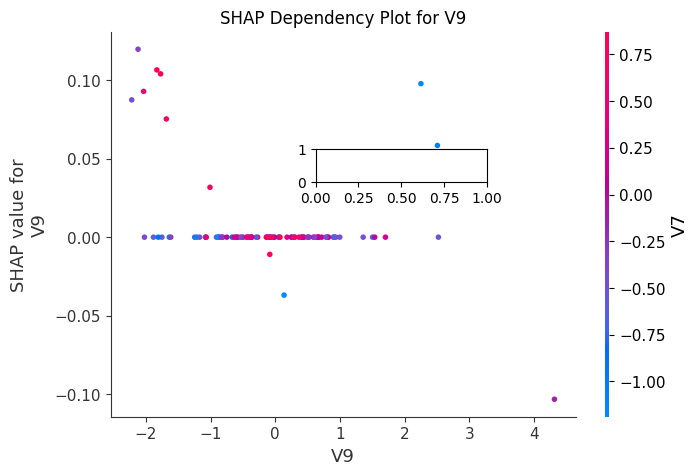

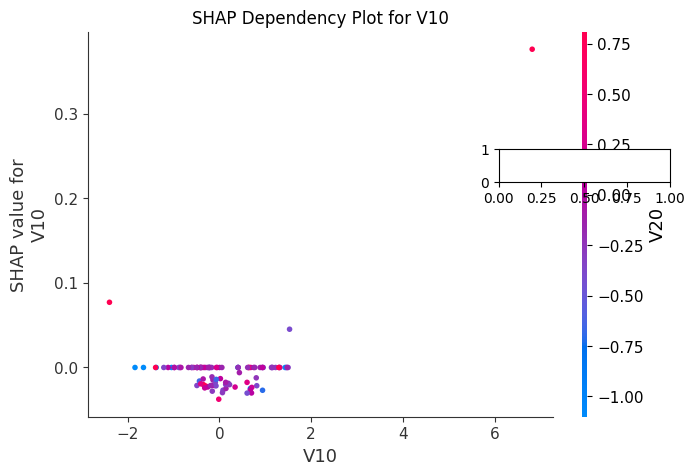

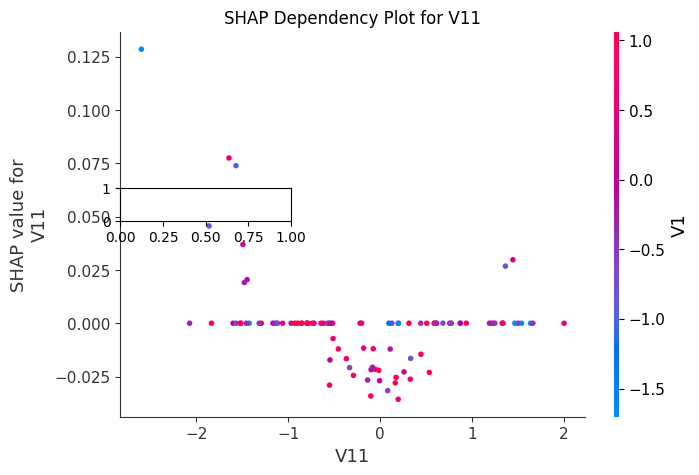

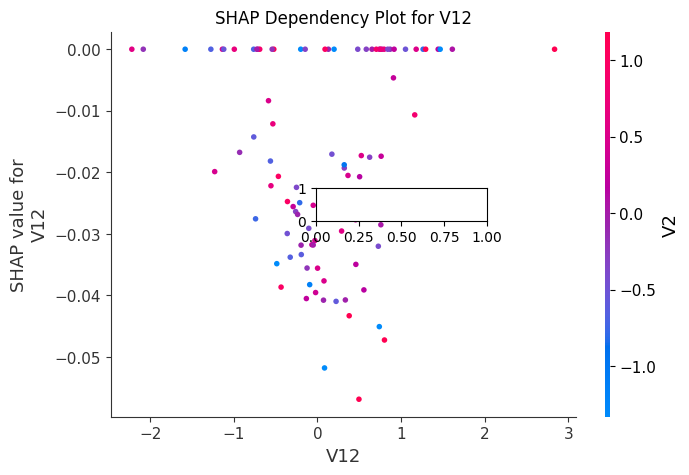

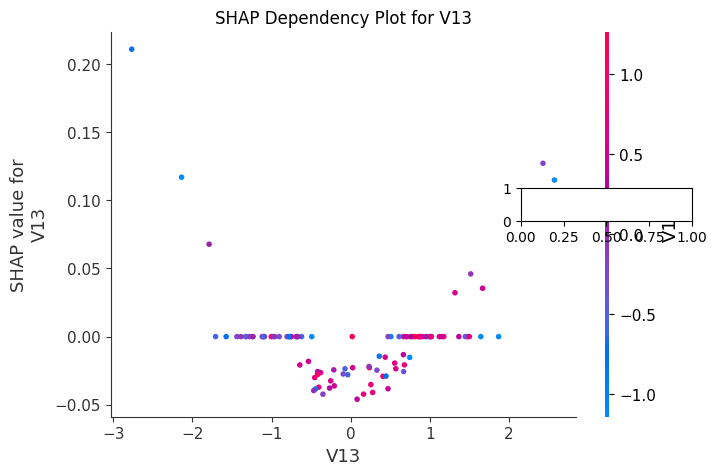

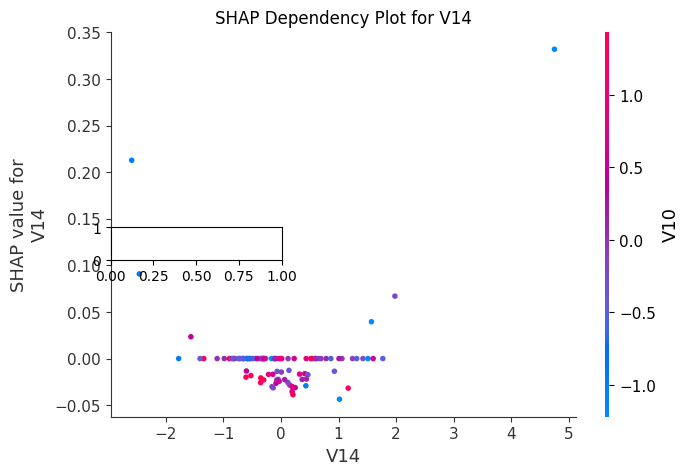

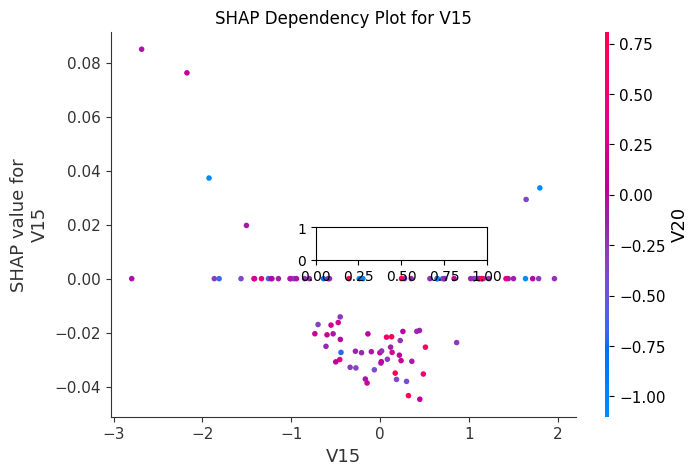

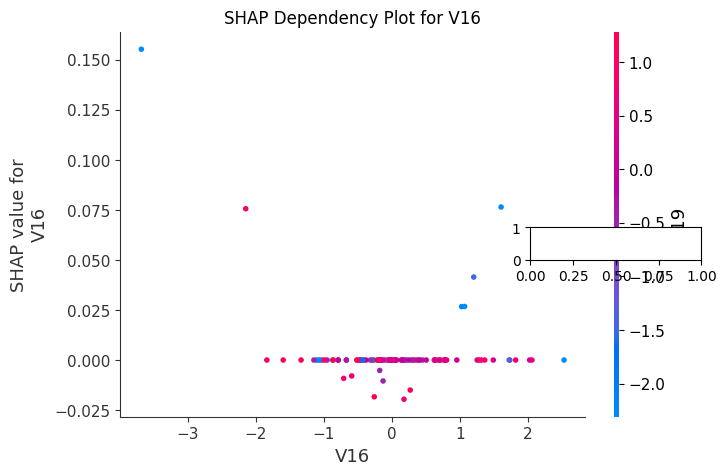

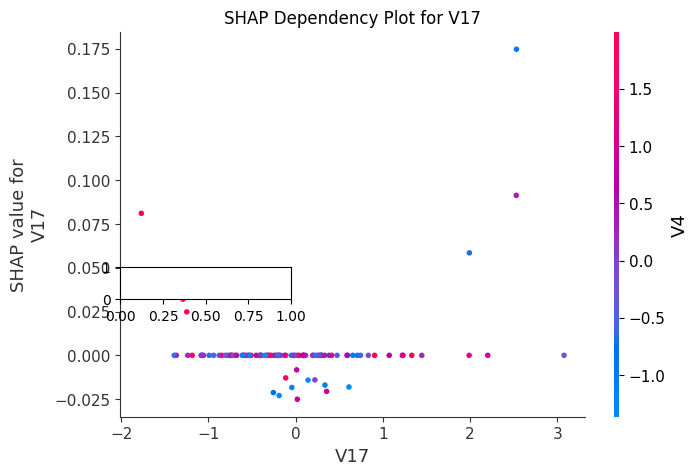

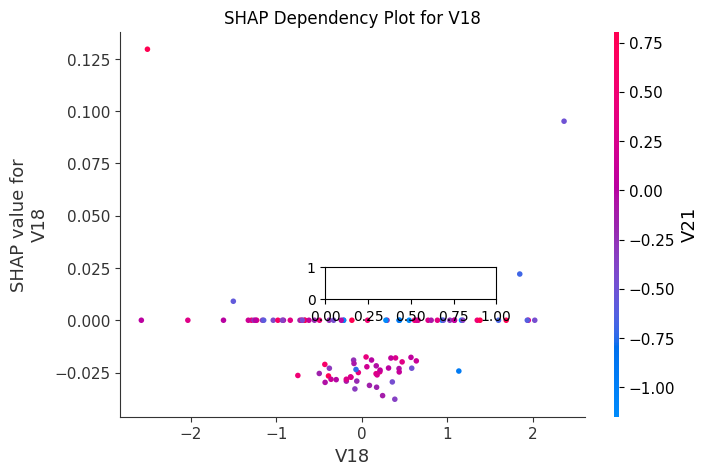

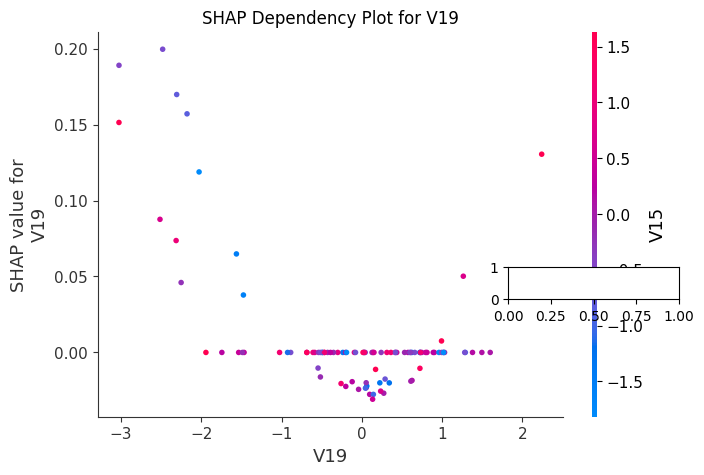

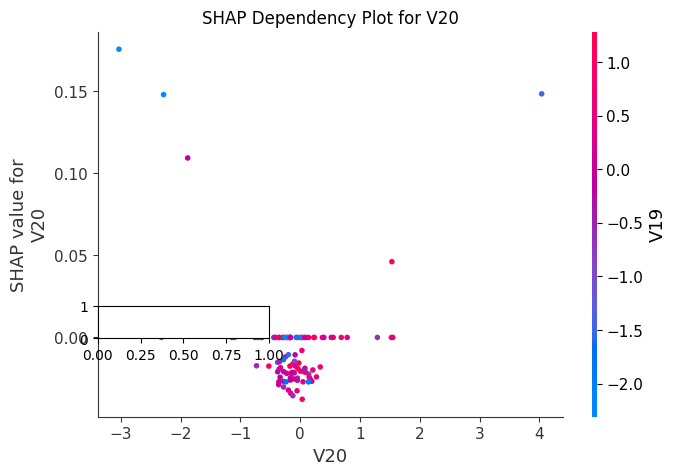

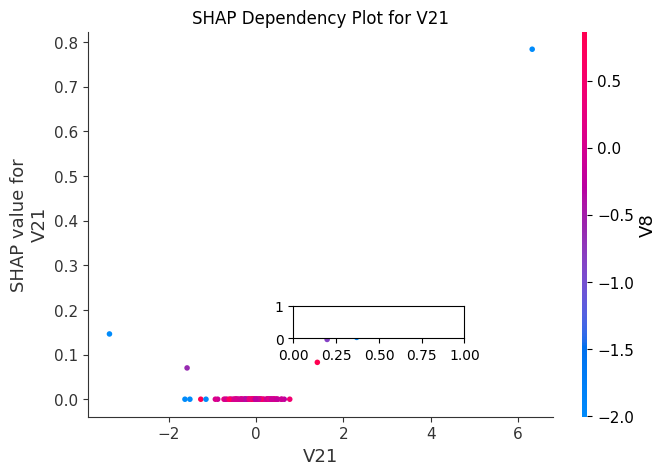

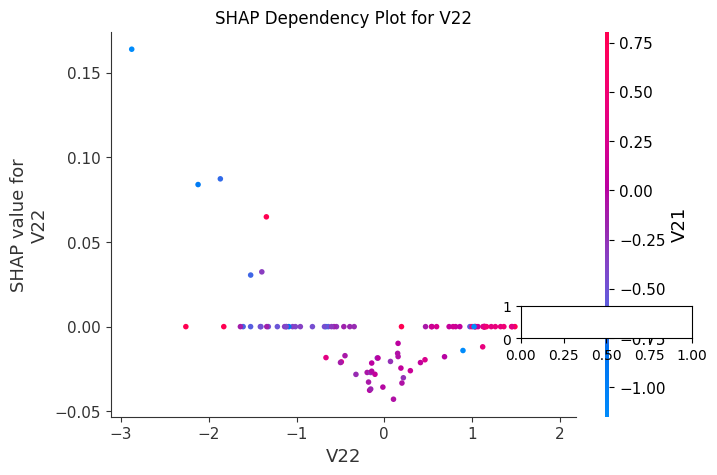

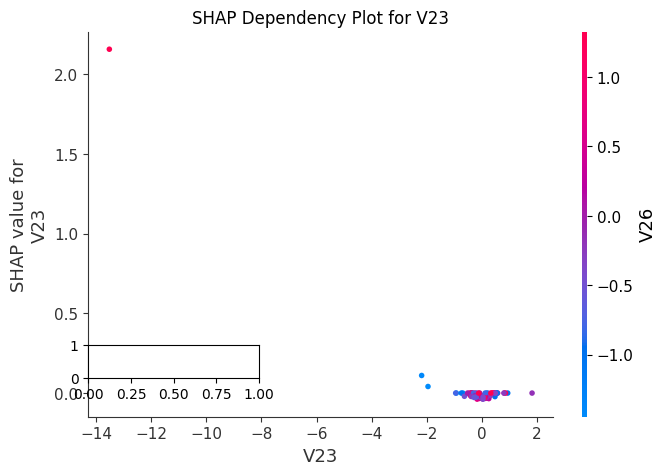

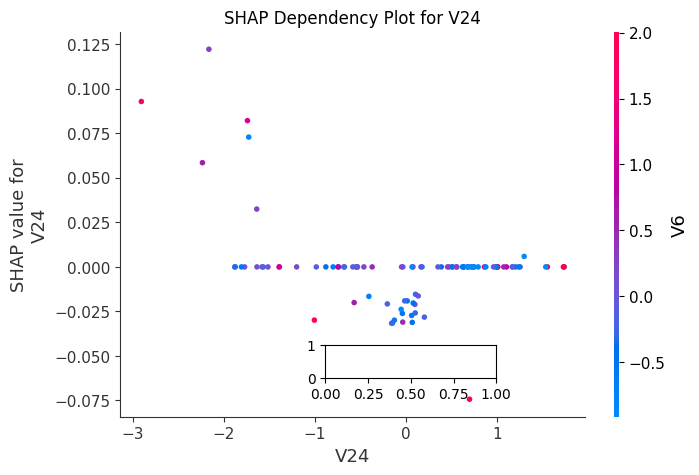

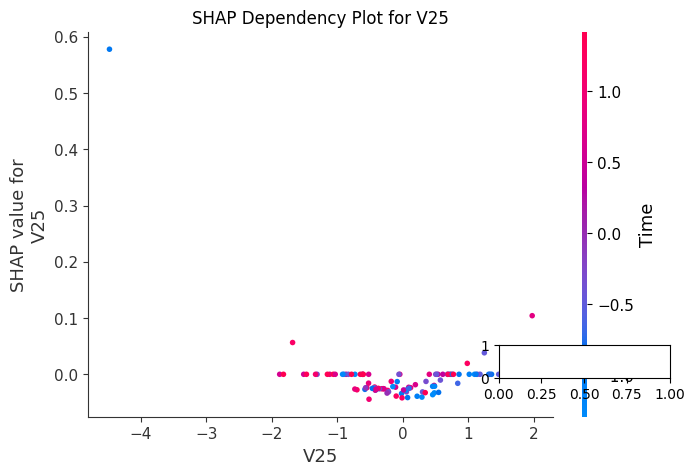

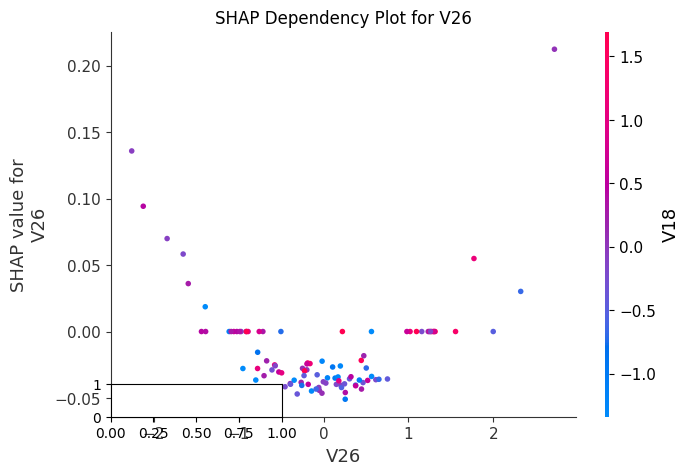

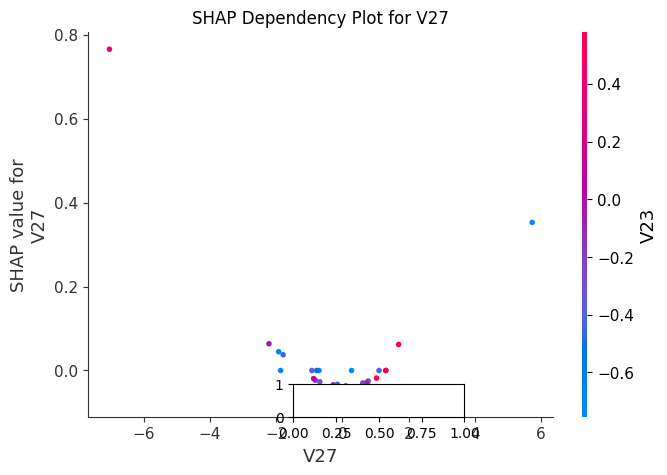

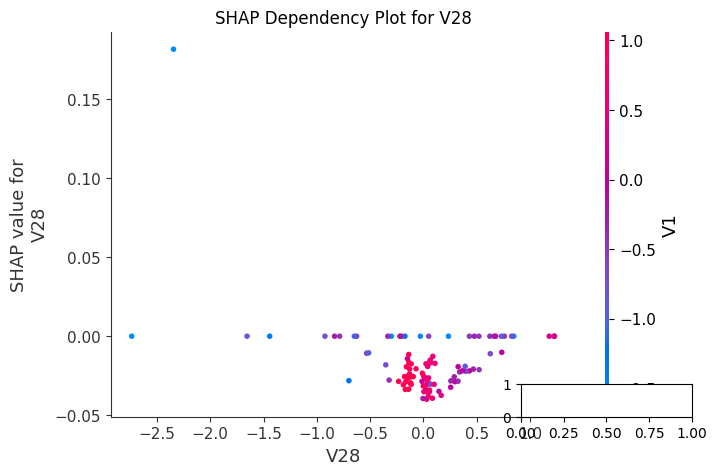

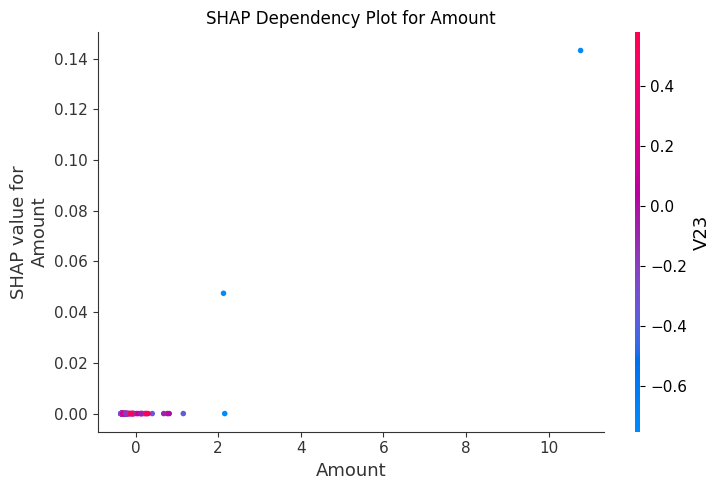

In [17]:
# SHAP Dependency Plots
num_features = len(feature_names)
n_cols = 3
n_rows = (num_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(feature_names):
    plt.subplot(n_rows, n_cols, i + 1)
    shap.dependence_plot(i, shap_values, X_test_final[:100], feature_names=feature_names, show=False)
    plt.title(f'SHAP Dependency Plot for {feature}')
plt.tight_layout()